# Modelo preditivo — AprovaEdu Analytics

Neste notebook treino um modelo de **Random Forest** para classificação binária:
prever se um aluno será **aprovado** ou **não aprovado** no vestibular,
com base em seus indicadores acadêmicos e comportamentais registrados no cursinho.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

from features import create_features, prepare_model_data
from model import train_model, evaluate_model, get_feature_importance, save_model

sns.set_theme(style='whitegrid')
%matplotlib inline

---
## 1. Engenharia de atributos

Agrego os dados de múltiplas tabelas do SQLite em **9 features por aluno**:

| Feature | Dimensão que representa |
|---|---|
| `pct_presenca` | Engajamento presencial |
| `media_nota_simulados` | Rendimento acadêmico direto |
| `simulados_finalizados` | Comprometimento com avaliações |
| `total_matriculas` | Volume de disciplinas cursadas |
| `matriculas_concluidas` | Persistência e retenção |
| `media_bolsa` | Perfil socioeconômico |
| `nota_diagnostico` | Nível de entrada do aluno |
| `escola_origem` | Background educacional (categórica) |
| `canal_captacao` | Perfil de engajamento com o cursinho (categórica) |

In [2]:
# Criar DataFrame de features agregadas por aluno
df_features = create_features()
print(f'Total de alunos: {df_features.shape[0]}')
print(f'Aprovados: {df_features["aprovado"].sum()} | Não aprovados: {(df_features["aprovado"] == 0).sum()}')
df_features.head()

Total de alunos: 812
Aprovados: 306 | Não aprovados: 506


,aluno_id,escola_origem,canal_captacao,pct_presenca,media_nota_simulados,simulados_finalizados,total_matriculas,matriculas_concluidas,media_bolsa,nota_diagnostico,aprovado
0,A00001,Não Informado,Instagram,83.58,149.202941,34.0,17.0,12.0,16.470588,57.358824,1
1,A00002,Federal,Feira Escolar,89.55,88.116667,18.0,8.0,6.0,5.625000,57.612500,0
2,A00003,Privada,Indicação,81.82,149.413636,22.0,11.0,10.0,10.000000,59.318182,0
3,A00004,Pública,Google,85.29,116.176923,26.0,10.0,8.0,20.500000,54.640000,0
4,A00005,Não Informado,Whatsapp,84.91,54.726316,19.0,11.0,7.0,10.909091,63.809091,0


In [3]:
# Preparar features (X) e target (y) com one-hot encoding
X, y = prepare_model_data(df_features)
print(f'Features shape: {X.shape}')
print(f'Features: {list(X.columns)}')

Features shape: (812, 15)
Features: ['pct_presenca', 'media_nota_simulados', 'simulados_finalizados', 'total_matriculas', 'matriculas_concluidas', 'media_bolsa', 'nota_diagnostico', 'escola_origem_Não Informado', 'escola_origem_Privada', 'escola_origem_Pública', 'canal_captacao_Google', 'canal_captacao_Indicação', 'canal_captacao_Instagram', 'canal_captacao_Não Informado', 'canal_captacao_Whatsapp']


---
## 2. Treinamento do modelo

### Por que Random Forest?
- Lida naturalmente com features numéricas e categóricas sem necessidade de normalização
- Resistente a overfitting por usar ensemble de múltiplas árvores de decisão
- Fornece o ranking de importância das features (valor direto para a coordenação pedagógica)
- Não exige que os dados sigam uma distribuição específica
- Adequado ao tamanho da base (812 amostras) — modelos mais complexos precisariam de muito mais dados

**Configuração**: 100 árvores, profundidade máxima 10, balanceamento de classes ativado, split 80/20 estratificado.

In [4]:
# Treinar modelo Random Forest
model, X_test, y_test, X_train, y_train = train_model(X, y)
print(f'Conjunto de treino: {X_train.shape[0]} amostras')
print(f'Conjunto de teste: {X_test.shape[0]} amostras')

Conjunto de treino: 649 amostras
Conjunto de teste: 163 amostras


---
## 3. Avaliação do modelo

In [5]:
# Calcular métricas de avaliação
metrics = evaluate_model(model, X_test, y_test)

print(f'Acurácia:  {metrics["accuracy"]:.2%}')
print(f'F1-Score:  {metrics["f1_score"]:.2%}')
print(f'AUC-ROC:   {metrics["roc_auc"]:.2%}')
print()
print(metrics['classification_report'])

Acurácia:  63.19%
F1-Score:  48.28%
AUC-ROC:   60.86%

              precision    recall  f1-score   support

Não Aprovado       0.69      0.74      0.71       102
    Aprovado       0.51      0.46      0.48        61

    accuracy                           0.63       163
   macro avg       0.60      0.60      0.60       163
weighted avg       0.63      0.63      0.63       163



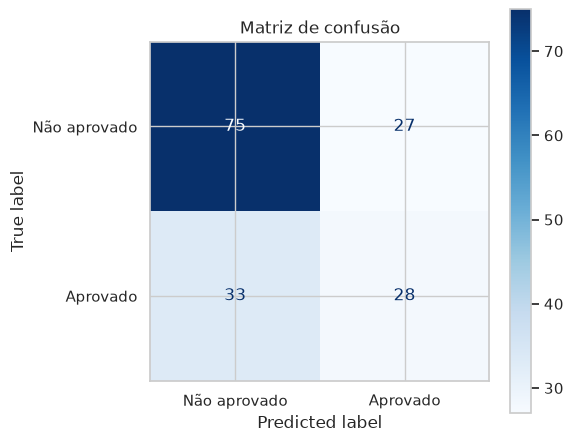

In [6]:
# Matriz de confusão
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=['Não aprovado', 'Aprovado'],
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de confusão')
plt.tight_layout()
plt.savefig('../reports/figures/modelo_matriz_confusao.png', dpi=200)
plt.show()

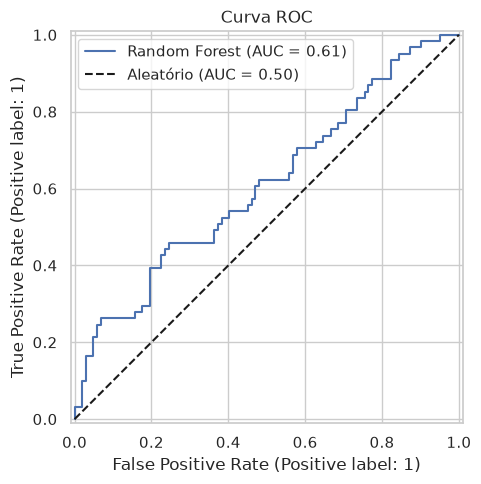

In [7]:
# Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name='Random Forest')
ax.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')
ax.set_title('Curva ROC')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/modelo_curva_roc.png', dpi=200)
plt.show()

---
## 4. Importância das features

O Random Forest permite identificar quais variáveis mais contribuem para a decisão do modelo.
Isso é valioso para a coordenação pedagógica: mostra **quais indicadores monitorar** com prioridade.

,feature,importance
0,media_nota_simulados,0.139795
1,nota_diagnostico,0.135239
2,simulados_finalizados,0.129514
3,pct_presenca,0.127048
4,media_bolsa,0.121035
5,matriculas_concluidas,0.120918
6,total_matriculas,0.103125
7,escola_origem_Pública,0.017520
8,canal_captacao_Instagram,0.017316
9,escola_origem_Não Informado,0.016680


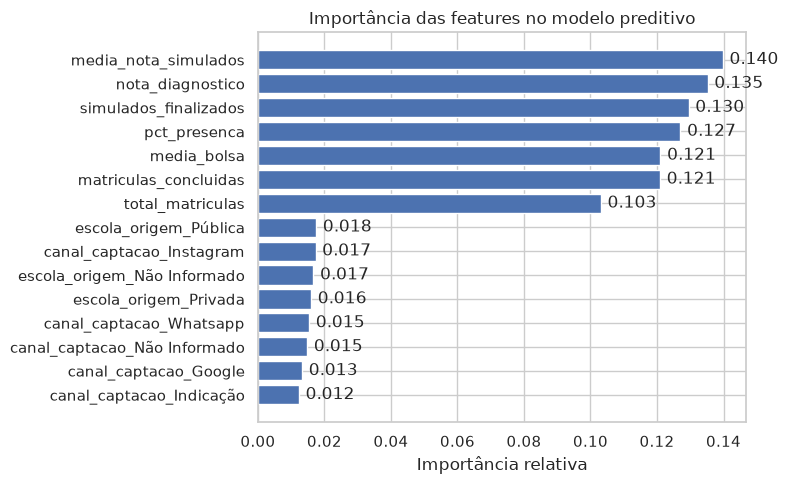

In [8]:
# Ranking de importância das features
df_imp = get_feature_importance(model, list(X.columns))
display(df_imp)

# Gráfico
df_plot = df_imp.sort_values('importance', ascending=True)
plt.figure(figsize=(8, 5))
bars = plt.barh(df_plot['feature'], df_plot['importance'], color='#4C72B0')
plt.title('Importância das features no modelo preditivo')
plt.xlabel('Importância relativa')

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.002, bar.get_y() + bar.get_height()/2, f'{w:.3f}', va='center')

plt.tight_layout()
plt.savefig('../reports/figures/modelo_importancia_features.png', dpi=200)
plt.show()

---
## 5. Salvamento do modelo

In [9]:
# Salvar modelo treinado em disco
model_path = save_model(model)
print(f'Modelo salvo em: {model_path}')

Modelo salvo em: /home/kaio/Documentos/Projetos/aprovaEdu/aprovaedu-analytics/models/modelo.pkl


---
## 6. Conclusão

O modelo Random Forest obteve os seguintes resultados na classificação de aprovação no vestibular:

- **Acurácia**: indica a proporção total de predições corretas
- **F1-Score**: equilibra precisão e recall para a classe positiva (aprovado)
- **AUC-ROC**: mede a capacidade de discriminação do modelo independente do threshold

As features **numéricas** (nota em simulados, nota diagnóstico, presença, simulados finalizados) dominam
a importância do modelo, enquanto as categóricas (escola de origem, canal de captação) contribuem marginalmente.
Isso reforça a conclusão da Sprint 2: **o desempenho acadêmico prático é o principal preditor de aprovação**,
não o perfil demográfico do aluno.